# Telecom Customer Churn Prediction

## Machine Learning Classification Project

### Project Objective
The objective of this project is to predict whether a telecom customer is likely to churn based on customer demographics, service usage, billing information, and customer satisfaction. Multiple machine learning models are trained and compared to identify the best performing model.

---

**Dataset:** Telecom Customer Churn Dataset

**Algorithms Used**
- Logistic Regression
- Decision Tree
- Random Forest
- K Nearest Neighbors
- Support Vector Machine
- Naive Bayes

**Best Model:** Random Forest

**Accuracy:** 87.56%


# 1. Import Libraries

In this section, we import the libraries required for data analysis, visualization, preprocessing, machine learning, and model evaluation.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 2. Load Dataset

The telecom churn dataset is loaded into a pandas DataFrame for further analysis and preprocessing.

In [ ]:
df=pd.read_csv("/content/telecom_churn_data.csv")
df

,Customer_ID,Age,Gender,Marital_Status,Dependents,City,State,Occupation,Education_Level,Annual_Income,...,Late_Payment_Count,Missed_Payment_Count,Satisfaction_Score,NPS_Score,ARPU,Customer_Lifetime_Value,Revenue_Last_3_Months,Revenue_Trend,Discount_Received,Churn_Flag
0,CUST_019453,41,Male,Divorced,1,Chicago,Illinois,IT/Tech,Bachelor's,105499.0,...,1,0,4.0,18.0,154.86,NaN,460.55,Stable,7.7,0
1,CUST_065143,41,Female,Married,3,San Diego,California,Government,PhD,92646.0,...,0,0,4.7,70.0,107.55,8626.68,318.30,Stable,17.4,0
2,CUST_010816,28,Male,Single,0,Chicago,Illinois,Business Owner,Bachelor's,141173.0,...,0,0,4.7,NaN,66.45,3301.85,202.74,Stable,16.4,0
3,CUST_018111,21,Female,Married,0,Dallas,Texas,Service Worker,Some College,33255.0,...,4,2,NaN,45.0,48.35,619.92,142.02,Stable,11.1,1
4,CUST_021697,53,Female,Married,0,San Antonio,Texas,Government,Bachelor's,54889.0,...,0,0,4.6,83.0,214.83,16732.56,660.81,Stable,12.5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74978,CUST_037195,26,Male,Single,0,Phoenix,Arizona,Healthcare,PhD,46984.0,...,2,2,3.4,21.0,58.29,2664.32,152.87,Declining,12.8,1
74979,CUST_006266,54,Female,Married,2,Chicago,Illinois,Professional,Master's,77889.0,...,2,1,3.7,28.0,35.62,1051.72,92.93,Declining,13.9,0
74980,CUST_054887,63,Male,Married,0,San Jose,California,Retired,Bachelor's,39984.0,...,0,0,4.7,97.0,94.20,11586.21,274.38,Stable,16.6,0
74981,CUST_000861,42,Female,Married,2,Dallas,Texas,Service Worker,High School,15000.0,...,0,0,2.5,-76.0,63.99,1190.07,197.34,Stable,14.0,1


# 3. Exploratory Data Analysis (EDA)

The dataset is explored to understand its structure, analyze the available features, identify missing values, examine data types, and gain insights before building machine learning models.


### 3.1 Display the First Five Rows

The `head()` function is used to display the first five rows of the dataset, providing an overview of the available features and the overall structure of the data.

In [ ]:
df.head()

,Customer_ID,Age,Gender,Marital_Status,Dependents,City,State,Occupation,Education_Level,Annual_Income,...,Late_Payment_Count,Missed_Payment_Count,Satisfaction_Score,NPS_Score,ARPU,Customer_Lifetime_Value,Revenue_Last_3_Months,Revenue_Trend,Discount_Received,Churn_Flag
0,CUST_019453,41,Male,Divorced,1,Chicago,Illinois,IT/Tech,Bachelor's,105499.0,...,1,0,4.0,18.0,154.86,NaN,460.55,Stable,7.7,0
1,CUST_065143,41,Female,Married,3,San Diego,California,Government,PhD,92646.0,...,0,0,4.7,70.0,107.55,8626.68,318.30,Stable,17.4,0
2,CUST_010816,28,Male,Single,0,Chicago,Illinois,Business Owner,Bachelor's,141173.0,...,0,0,4.7,NaN,66.45,3301.85,202.74,Stable,16.4,0
3,CUST_018111,21,Female,Married,0,Dallas,Texas,Service Worker,Some College,33255.0,...,4,2,NaN,45.0,48.35,619.92,142.02,Stable,11.1,1
4,CUST_021697,53,Female,Married,0,San Antonio,Texas,Government,Bachelor's,54889.0,...,0,0,4.6,83.0,214.83,16732.56,660.81,Stable,12.5,0


### 3.2 Check Dataset Shape

The shape of the dataset is checked to determine the total number of rows and columns.

In [ ]:
print("Dataset Shape:", df.shape)

Dataset Shape: (74983, 42)


### 3.3 Display Dataset Information

The `info()` function provides details about each column, including the data type, number of non null values, and memory usage.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74983 entries, 0 to 74982
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  74983 non-null  object 
 1   Age                          74983 non-null  int64  
 2   Gender                       74983 non-null  object 
 3   Marital_Status               74983 non-null  object 
 4   Dependents                   74983 non-null  int64  
 5   City                         74983 non-null  object 
 6   State                        74983 non-null  object 
 7   Occupation                   74983 non-null  object 
 8   Education_Level              74983 non-null  object 
 9   Annual_Income                71238 non-null  float64
 10  Tenure_Months                74983 non-null  int64  
 11  Plan_Type                    74983 non-null  object 
 12  Contract_Type                74983 non-null  object 
 13  Monthly_Charges 

### 3.4 Statistical Summary

Descriptive statistics are generated to understand the distribution of numerical features such as mean, minimum, maximum, and standard deviation.

In [ ]:
df.describe()

,Age,Dependents,Annual_Income,Tenure_Months,Monthly_Charges,Total_Bill_Amount,Auto_Pay,International_Plan,Roaming_Usage_GB,Family_Plan,...,Reward_Points,Late_Payment_Count,Missed_Payment_Count,Satisfaction_Score,NPS_Score,ARPU,Customer_Lifetime_Value,Revenue_Last_3_Months,Discount_Received,Churn_Flag
count,74983.000000,74983.000000,71238.000000,74983.000000,74983.000000,74983.000000,74983.000000,74983.000000,71965.000000,74983.000000,...,74983.000000,74983.000000,74983.000000,70182.000000,68704.000000,74983.000000,69637.000000,74983.000000,69868.000000,74983.000000
mean,37.532054,0.877892,72655.271976,36.198618,91.366221,3482.226828,0.470667,0.197765,0.785082,0.393943,...,15190.366963,0.597429,0.162463,4.081849,38.261178,97.664785,4066.502984,288.443547,10.896893,0.199459
std,12.349788,1.069421,63657.384817,25.738165,53.762044,3642.154191,0.499142,0.398316,2.280997,0.488626,...,11652.166606,0.898551,0.468968,0.698877,44.430112,56.565611,4225.838338,170.601223,6.197266,0.399596
min,18.000000,0.000000,15000.000000,1.000000,15.510000,17.710000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.200000,-100.000000,18.430000,50.000000,47.500000,0.000000,0.000000
25%,28.000000,0.000000,29638.000000,16.000000,49.020000,945.265000,0.000000,0.000000,0.000000,0.000000,...,6404.000000,0.000000,0.000000,3.800000,15.000000,52.630000,1168.710000,154.470000,6.100000,0.000000
50%,36.000000,1.000000,55249.000000,31.000000,81.930000,2276.940000,0.000000,0.000000,0.000000,0.000000,...,12645.000000,0.000000,0.000000,4.300000,46.000000,87.870000,2646.630000,257.510000,10.800000,0.000000
75%,45.000000,2.000000,100521.000000,52.000000,115.440000,4844.465000,1.000000,0.000000,0.000000,1.000000,...,21623.500000,1.000000,0.000000,4.600000,71.000000,124.350000,5531.020000,368.445000,15.600000,0.000000
max,75.000000,4.000000,749498.000000,120.000000,348.080000,37605.360000,1.000000,1.000000,20.000000,1.000000,...,82026.000000,7.000000,6.000000,4.900000,100.000000,375.730000,27998.450000,1224.850000,32.800000,1.000000


### 3.5 Check Duplicate Records

The dataset is checked for duplicate records to ensure that repeated observations do not affect model performance.

In [ ]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 538


### 3.6 Check Missing Values

The dataset is checked for missing values to determine whether any preprocessing is required before training the machine learning models.

In [ ]:
print(df.isna().sum().sort_values(ascending=False))

NPS_Score                      6279
Customer_Lifetime_Value        5346
Discount_Received              5115
Satisfaction_Score             4801
Last_Login_Days_Ago            4236
Annual_Income                  3745
Roaming_Usage_GB               3018
Monthly_Data_Usage_GB          2909
Age                               0
Customer_ID                       0
Education_Level                   0
Occupation                        0
State                             0
City                              0
Marital_Status                    0
Dependents                        0
Gender                            0
Tenure_Months                     0
International_Plan                0
Auto_Pay                          0
Number_of_Lines                   0
Plan_Type                         0
Total_Bill_Amount                 0
Payment_Method                    0
Contract_Type                     0
Monthly_Charges                   0
Customer_Service_Calls            0
Streaming_Usage_Hours       

### EDA Summary

The exploratory data analysis shows that the dataset contains **74,983 customer records** and **42 features**.

The dataset was examined for data types, missing values, duplicate records, summary statistics, and the distribution of the target variable. These insights helped identify data quality issues and guided the preprocessing steps used before model training.

# 4. Data Visualization

Visualizations are created to better understand customer behavior, feature distributions, and relationships with customer churn.

### 4.1 Customer Churn Distribution

This visualization shows the proportion of customers who stayed and customers who churned.

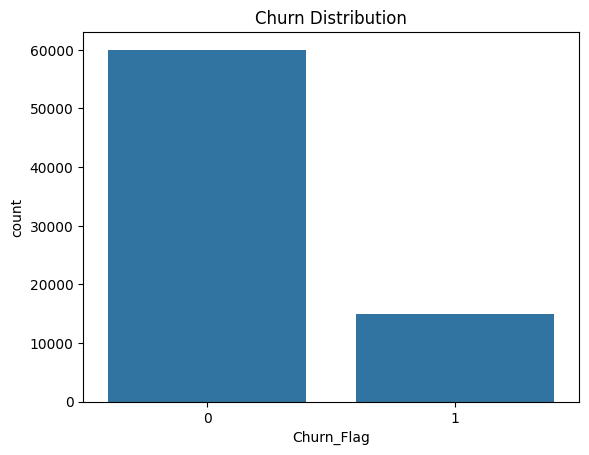

In [ ]:
sns.countplot(x='Churn_Flag',data=df)
plt.title("Churn Distribution")
plt.show()

### 4.2 Churn Percentage

The percentage of customers who stayed and churned is calculated to understand the distribution of the target variable before training the machine learning models.

In [ ]:
churn_summary = pd.DataFrame({"Count": df['Churn_Flag'].value_counts(),
                              "Percentage (%)": round(df['Churn_Flag'].value_counts(normalize=True) * 100, 2)})

churn_summary

,Count,Percentage (%)
Churn_Flag,,
0,60027,80.05
1,14956,19.95


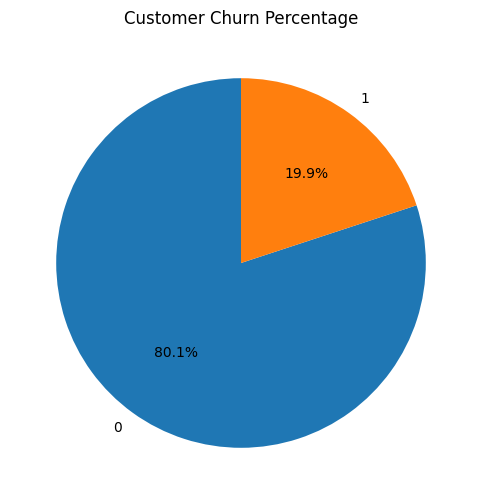

In [ ]:
plt.figure(figsize=(6,6))
df['Churn_Flag'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90)
plt.title("Customer Churn Percentage")
plt.ylabel("")
plt.show()

### Interpretation

Approximately **79.80%** of customers stayed with the telecom company, while **20.20%** of customers churned. This indicates that the dataset is moderately imbalanced, with a larger proportion of retained customers than churned customers.

### 4.3 Age Distribution

This histogram illustrates the distribution of customer ages.

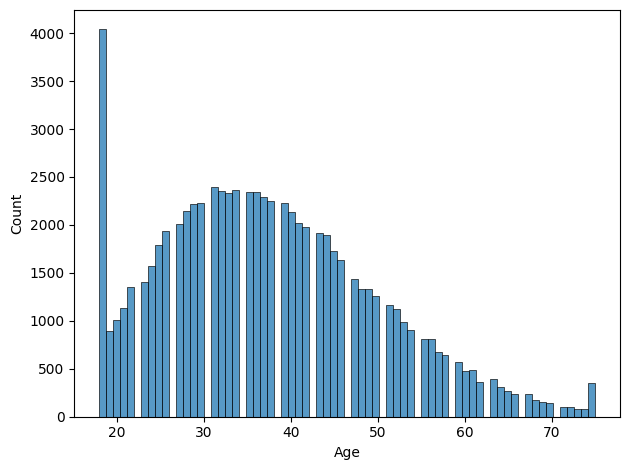

In [ ]:
sns.histplot(df['Age'])
plt.tight_layout()

### 4.4 Age Outlier Detection

# A box plot is used to identify the presence of outliers in the Age feature.

<Axes: xlabel='Age'>

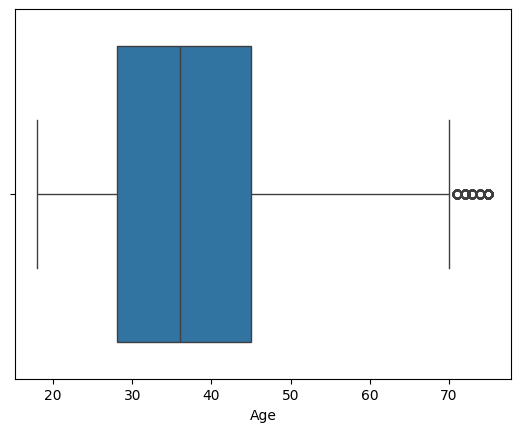

In [ ]:
sns.boxplot(x=df['Age'])

### 4.5 Gender Distribution

This chart shows the distribution of male and female customers in the dataset.

<Axes: xlabel='Gender', ylabel='count'>

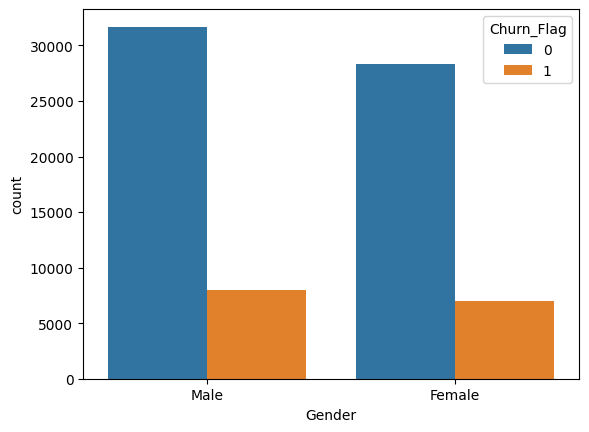

In [ ]:
sns.countplot(x=df['Gender'],hue='Churn_Flag',data=df)

### 4.6 Average Satisfaction Score by Churn

This analysis compares the average satisfaction score between customers who churned and customers who stayed.

In [ ]:
df.groupby('Churn_Flag')['Satisfaction_Score'].mean()

,Satisfaction_Score
Churn_Flag,
0,4.276012
1,3.289349


### 4.7 Complaint Count by Churn Status

This box plot compares complaint counts for customers who churned and customers who stayed.

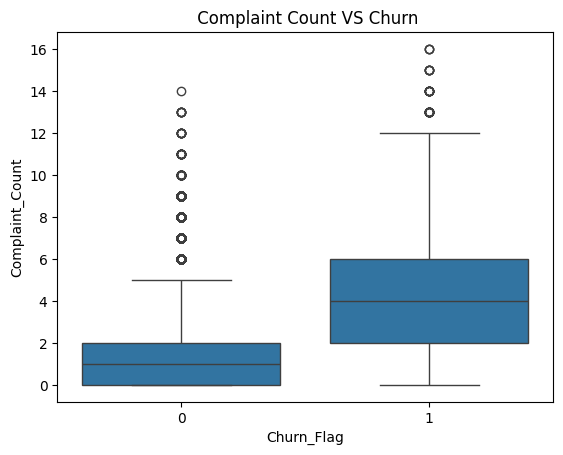

In [ ]:
sns.boxplot(x='Churn_Flag',y='Complaint_Count',data=df)
plt.title(" Complaint Count VS Churn")
plt.show()

### 4.8 Correlation Matrix

The correlation matrix is generated to understand the relationships among numerical features.

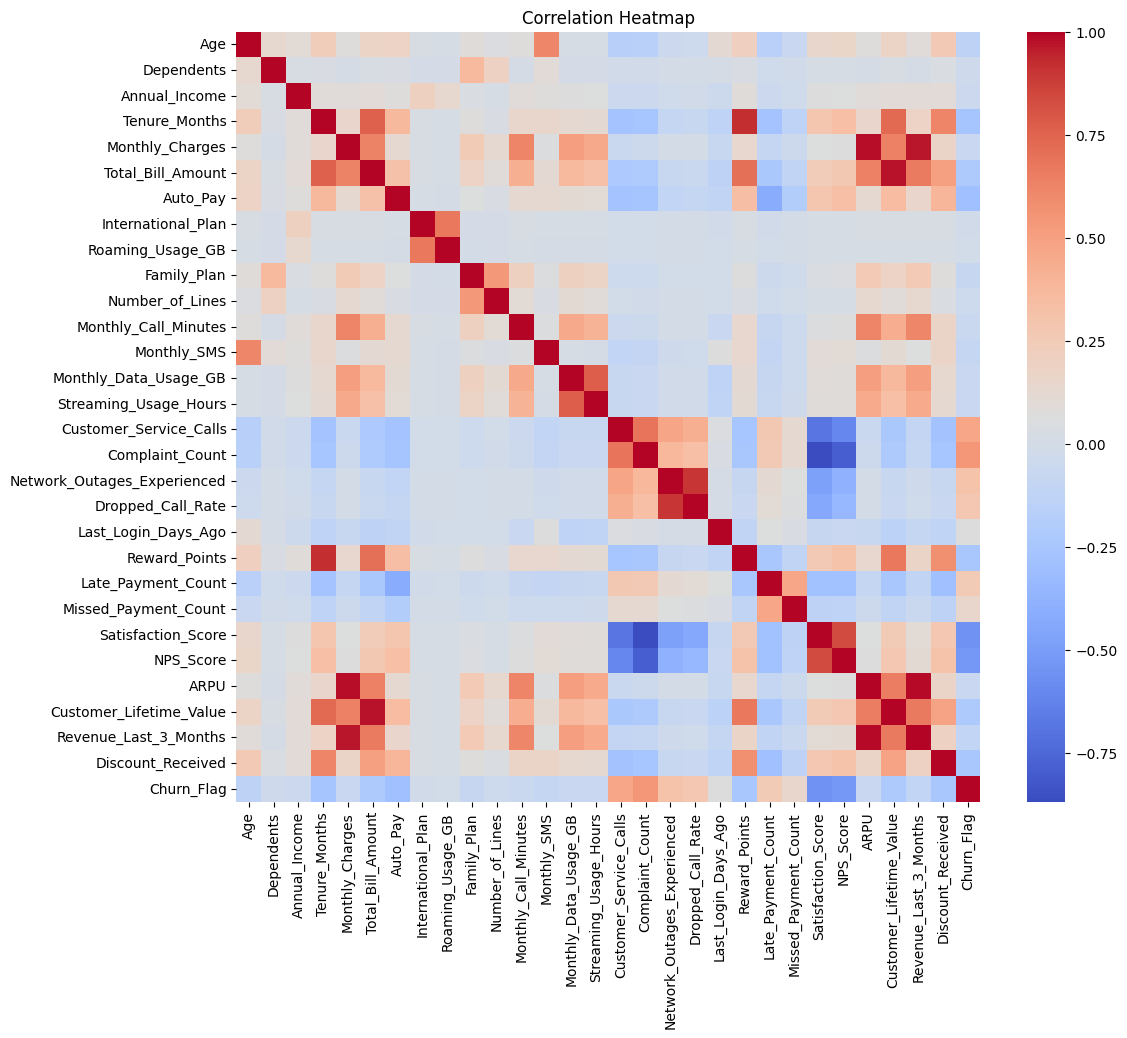

In [ ]:
corr=df.select_dtypes(include='number').corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr,cmap="coolwarm",annot=False)
plt.title("Correlation Heatmap")
plt.show()

### 4.9 Churn Rate by Plan Type

This analysis shows the percentage of customers who churned under each subscription plan.

In [ ]:
df.groupby('Plan_Type')['Churn_Flag'].mean()*100

,Churn_Flag
Plan_Type,
Business,14.632945
Family,14.219960
Postpaid,21.421754
Prepaid,23.319539


### Data Visualization Summary

The visualizations reveal several important insights into customer churn. Complaint count, customer satisfaction, age, and customer service interactions appear to influence churn. These observations provide valuable guidance for feature selection and model development.

# 5. Data Preprocessing

In this section, the dataset is prepared for machine learning by removing unnecessary columns, handling categorical variables, selecting features, and preparing the data for model training.

### Dataset Preparation Summary

The original dataset contained **74,983 customer records**.

During preprocessing, missing values were handled using appropriate imputation techniques, categorical variables were encoded using one hot encoding, and numerical features were standardized using StandardScaler. The **Customer_ID** column was removed because it did not contribute to prediction.

The dataset size remained **74,983 customer records**, as preprocessing involved transforming the data rather than removing observations. The processed dataset was then divided into training and testing sets using a **70:30 train test split** for model training and evaluation.

### 5.1 Remove Unnecessary Columns

The `Customer_ID` column is removed because it is a unique identifier and does not contribute to predicting customer churn.

In [ ]:
df=df.drop(['Customer_ID'],axis=1)

### 5.2 Handle Missing Values

Missing values are handled separately for numerical and categorical features to ensure a complete dataset for model training.

In [ ]:
for col in df.select_dtypes(include=['int64','float64']):
  df[col]=df[col].fillna(df[col].median())

for col in df.select_dtypes(include=['object']):
  df[col]=df[col].fillna(df[col].mode()[0])

### 5.3 Separate Features and Target Variable

The dataset is divided into independent features (X) and the target variable (y).

In [ ]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

### 5.4 Identify Categorical Features

Categorical columns are identified before applying encoding techniques.

In [ ]:
categorical_columns=x.select_dtypes(include=['object'])
categorical_columns

,Gender,Marital_Status,City,State,Occupation,Education_Level,Plan_Type,Contract_Type,Payment_Method,App_Usage_Frequency,Revenue_Trend
0,Male,Divorced,Chicago,Illinois,IT/Tech,Bachelor's,Family,Two-Year,Debit Card,Medium,Stable
1,Female,Married,San Diego,California,Government,PhD,Family,One-Year,Check,High,Stable
2,Male,Single,Chicago,Illinois,Business Owner,Bachelor's,Postpaid,Month-to-Month,Digital Wallet,High,Stable
3,Female,Married,Dallas,Texas,Service Worker,Some College,Prepaid,Month-to-Month,Check,High,Stable
4,Female,Married,San Antonio,Texas,Government,Bachelor's,Family,Two-Year,Debit Card,Low,Stable
...,...,...,...,...,...,...,...,...,...,...,...
74978,Male,Single,Phoenix,Arizona,Healthcare,PhD,Postpaid,Month-to-Month,Digital Wallet,Medium,Declining
74979,Female,Married,Chicago,Illinois,Professional,Master's,Prepaid,Month-to-Month,Bank Transfer,Low,Declining
74980,Male,Married,San Jose,California,Retired,Bachelor's,Postpaid,Two-Year,Bank Transfer,High,Stable
74981,Female,Married,Dallas,Texas,Service Worker,High School,Postpaid,Month-to-Month,Credit Card,Low,Stable


### 5.5 Encode Categorical Variables

One Hot Encoding is applied to convert categorical variables into numerical format.

In [ ]:
x=pd.get_dummies(x,drop_first=True)
x

,Age,Dependents,Annual_Income,Tenure_Months,Monthly_Charges,Total_Bill_Amount,Auto_Pay,International_Plan,Roaming_Usage_GB,Family_Plan,...,Contract_Type_One-Year,Contract_Type_Two-Year,Payment_Method_Check,Payment_Method_Credit Card,Payment_Method_Debit Card,Payment_Method_Digital Wallet,App_Usage_Frequency_Low,App_Usage_Frequency_Medium,Revenue_Trend_Growing,Revenue_Trend_Stable
0,41,1,105499.0,52,138.15,7554.91,0,1,1.43,1,...,False,True,False,False,True,False,False,True,False,True
1,41,3,92646.0,70,109.59,7327.32,1,0,0.00,1,...,True,False,True,False,False,False,False,False,False,True
2,28,0,141173.0,46,60.16,2693.66,1,1,3.54,0,...,False,False,False,False,False,True,False,False,False,True
3,21,0,33255.0,13,41.81,554.92,0,0,0.00,0,...,False,False,True,False,False,False,False,False,False,True
4,53,0,54889.0,83,182.64,14362.37,1,0,0.00,1,...,False,True,False,False,True,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74978,26,0,46984.0,48,51.93,2335.06,0,0,0.00,0,...,False,False,False,False,False,True,False,True,False,False
74979,54,2,77889.0,32,33.96,1011.59,0,0,0.00,1,...,False,False,False,False,False,False,True,False,False,False
74980,63,0,39984.0,111,86.39,9136.31,1,0,0.00,0,...,False,True,False,False,False,False,False,False,False,True
74981,42,2,15000.0,17,55.25,882.39,1,0,0.00,0,...,False,False,False,True,False,False,True,False,False,True


### Preprocessing Summary

The preprocessing stage involved:

• Removing Customer_ID.

• Filling missing numerical values with the median.

• Filling missing categorical values with the mode.

• Encoding categorical variables using One Hot Encoding.

• Separating features and target.

The processed data is now ready for model training.

# 6. Train Test Split

The dataset is split into training and testing sets to evaluate the performance of machine learning models on unseen data.

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=42)

### Train Test Split Summary

The dataset was divided into:

• 70% Training Data

• 30% Testing Data

The training data is used to train the model, while the testing data evaluates performance on unseen customers.

# 7. Feature Scaling

Numerical features are standardized using StandardScaler to improve model performance.

### Why Feature Scaling?

StandardScaler standardizes numerical features so they have a mean of 0 and a standard deviation of 1.

This improves the performance of distance based algorithms such as KNN and SVM.

Although Random Forest does not require scaling, the same scaled dataset is used for consistent comparison across models.

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

# 8. Model Building

Multiple machine learning algorithms are trained and compared to identify the best performing model for customer churn prediction.

## 8.1 Logistic Regression

Logistic Regression is used as a baseline classification algorithm to predict customer churn.

In [ ]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
from sklearn.metrics import accuracy_score
lr_score=accuracy_score(y_test,y_pred)
print("Linnear Model Accuracy : ",lr_score*100)

Linnear Model Accuracy :  87.42387197154923


In [ ]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm

array([[17107,   883],
       [ 1946,  2559]])

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred,zero_division=0))

              precision    recall  f1-score   support

           0       0.90      0.95      0.92     17990
           1       0.74      0.57      0.64      4505

    accuracy                           0.87     22495
   macro avg       0.82      0.76      0.78     22495
weighted avg       0.87      0.87      0.87     22495



## 8.2 Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
tree=DecisionTreeClassifier(random_state=42)
tree.fit(x_train,y_train)
y_pred=tree.predict(x_test)
dt_score=accuracy_score(y_test,y_pred)
print(" Decision Tree Accuracy : ",dt_score*100)

 Decision Tree Accuracy :  81.72038230717938


## 8.3 Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(random_state=42)
rf.fit(x_train,y_train)
y_pred=rf.predict(x_test)
rf_score=accuracy_score(y_test,y_pred)
print("Random Forest Accuracy : ",rf_score*100)

Random Forest Accuracy :  87.56168037341632


## 8.4 K Nearest Neighbors

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
knn.fit(x_train,y_train)
y_pred=knn.predict(x_test)
knn_score=accuracy_score(y_test,y_pred)
print("KNN Accuracy : ",knn_score*100)

KNN Accuracy :  83.89419871082463


## 8.5 Support Vector Machine

In [ ]:
from sklearn.svm import SVC
svm=SVC(random_state=42)
svm.fit(x_train,y_train)
y_pred=svm.predict(x_test)
svm_score=accuracy_score(y_test,y_pred)
print("SVM Model Accuracy : ",svm_score*100)

SVM Model Accuracy :  87.2549455434541


## 8.6 Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
nb=GaussianNB()
nb.fit(x_train,y_train)
y_pred=nb.predict(x_test)
nb_score=accuracy_score(y_test,y_pred)
print("Naive Bayes Accuracy : ",nb_score*100)

Naive Bayes Accuracy :  77.55501222493888


# 9. Model Comparison

The performance of all machine learning models is compared using accuracy to identify the best performing algorithm.

In [ ]:
accuracy = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'KNN',
        'SVM',
        'Naive Bayes'
    ],
    'Accuracy':[
        lr_score,
        dt_score,
        rf_score,
        knn_score,
        svm_score,
        nb_score
            ]
})
accuracy['Accuracy']=accuracy['Accuracy'] *100
accuracy=accuracy.sort_values(by='Accuracy',ascending=False)
accuracy

,Model,Accuracy
2,Random Forest,87.561680
0,Logistic Regression,87.423872
4,SVM,87.254946
3,KNN,83.894199
1,Decision Tree,81.720382
5,Naive Bayes,77.555012


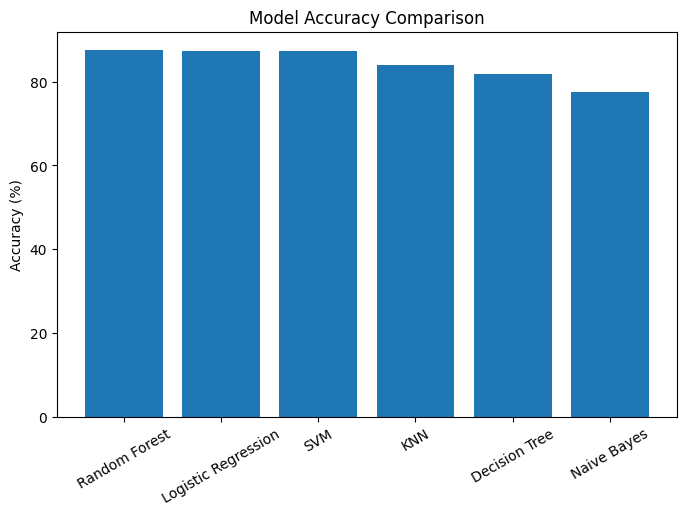

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(accuracy["Model"], accuracy["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=30)
plt.show()

# 10. Save Model

The trained Random Forest model and StandardScaler are saved using Joblib for deployment in the Streamlit application.

In [ ]:
import joblib

joblib.dump(rf, "telecom_churn_Project.pkl")
joblib.dump(lr, "telecom_churn_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

### Model Saving Summary

The trained Random Forest model and the fitted StandardScaler are saved using Joblib.

These files will later be loaded into the Streamlit application to make predictions without retraining.

# 11. Model Evaluation

The Random Forest model is evaluated using multiple performance metrics including accuracy, confusion matrix, and classification report.

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
y_pred = rf.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8756168037341632
[[17248   742]
 [ 2056  2449]]
              precision    recall  f1-score   support

           0       0.89      0.96      0.92     17990
           1       0.77      0.54      0.64      4505

    accuracy                           0.88     22495
   macro avg       0.83      0.75      0.78     22495
weighted avg       0.87      0.88      0.87     22495



### Evaluation Summary

The Random Forest model achieved strong predictive performance.

The confusion matrix shows that most customers were classified correctly.

The classification report indicates balanced precision, recall, and F1 score, making the model suitable for churn prediction.

# 12. Feature Importance

Feature importance analysis helps identify which features contribute the most to predicting customer churn. This enables us to understand the key factors influencing customer retention and supports better business decision making.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
importance = pd.DataFrame({"Feature": x.columns,"Importance": rf.feature_importances_})
importance = importance.sort_values(by="Importance",ascending=False)
print(importance.head(10))

                        Feature  Importance
16              Complaint_Count    0.114084
23           Satisfaction_Score    0.085297
24                    NPS_Score    0.081472
15       Customer_Service_Calls    0.052924
18            Dropped_Call_Rate    0.036522
20                Reward_Points    0.031332
28            Discount_Received    0.031179
26      Customer_Lifetime_Value    0.029271
5             Total_Bill_Amount    0.029099
17  Network_Outages_Experienced    0.028449


### 12.1 Top 10 Important Features

The Random Forest model assigns an importance score to each feature based on its contribution to prediction. The following bar chart displays the ten most influential features.

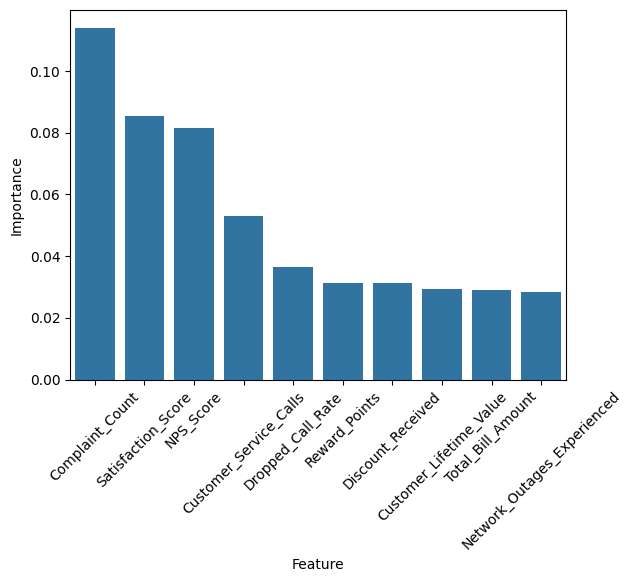

<Figure size 1200x600 with 0 Axes>

In [ ]:
sns.barplot(data=importance.head(10), x="Feature", y="Importance")
plt.xticks(rotation=45)
plt.figure(figsize=(12,6))
plt.show()


### Feature Importance Summary

Complaint Count

Satisfaction Score

NPS Score

Customer Service Calls

Dropped Call Rate

were the strongest indicators of customer churn.

These features can help telecom companies identify customers who are at higher risk of leaving.

# 13. Conclusion

In this project, a Telecom Customer Churn Prediction model was successfully developed using Machine Learning.

The dataset was explored, cleaned, visualized, and preprocessed before training multiple classification algorithms.

Six classification models were evaluated and compared based on their prediction accuracy.

Among all the models tested, the Random Forest Classifier achieved the highest accuracy of **87.56%**, making it the best-performing model for customer churn prediction.

Feature importance analysis revealed that Complaint Count, Satisfaction Score, NPS Score, Customer Service Calls, and Dropped Call Rate were the most influential factors affecting customer churn.

The trained Random Forest model and the preprocessing scaler were saved successfully and are ready for deployment using Streamlit to perform real time customer churn prediction.